<a href="https://colab.research.google.com/github/ahalyamukundan24/Case_Study_on_Deep_Learning/blob/main/Assignment_on_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning with Keras - Regression Assignment

## 1. Import Libraries


In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load Dataset

In [2]:
data = fetch_california_housing()
df = pd.DataFrame(data.data,columns=data.feature_names)
df['Target'] = data.target

df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


### Explanation:

#### The dataset contains information about houses in different areas of California. The target variable represents median house value.

## 3. Descriptive Statictics

In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Explanation:

#### The dataset shows variation in features like population and income. Some features have large ranges indicating possible curvature.

## 4. Visualization

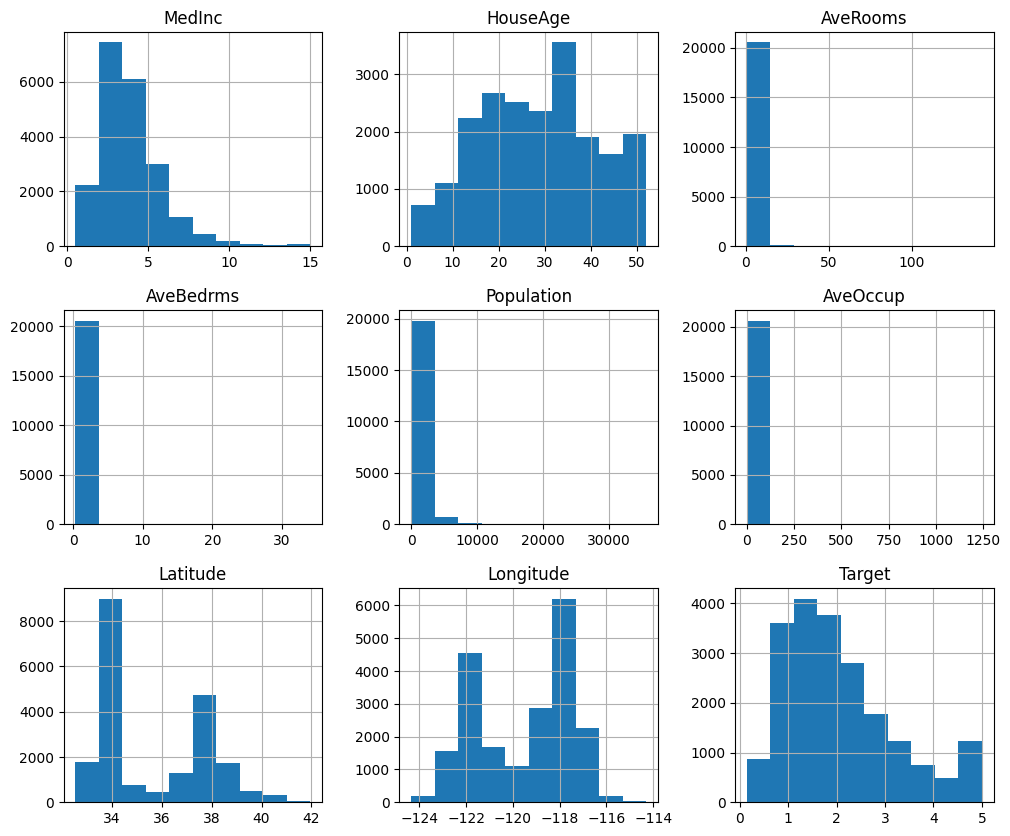

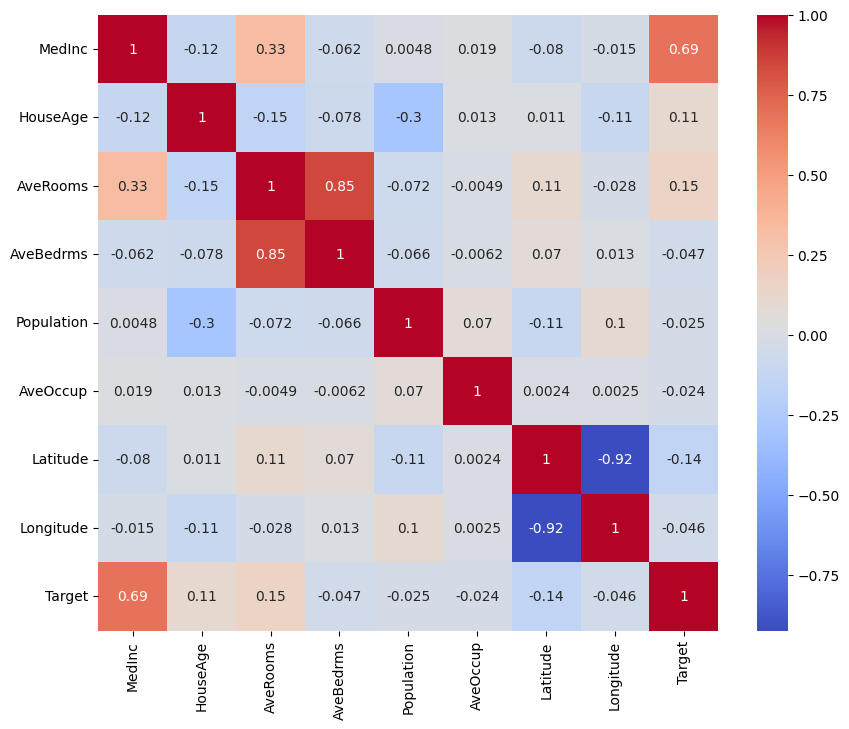

In [4]:
df.hist(figsize=(12,10))
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

### Explanation:

#### Median income shows strong correlation with house value. Some features are weakly correlated.

## 5. Train-Test Split

In [5]:
X = df.drop('Target',axis=1)
y = df['Target']

X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.3,random_state=42)
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

### Explanation:

#### The dataset is split into training (70%), validation(15%), and test (15%).

## 6. Feature Scaling

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Explanation:

#### Feature scaling is applied so that all values are in a similar range. The scaler is fitted only on training data to prevent data leakage.

## 7. Model Building

In [7]:
model = Sequential([
    Dense(64, activation='relu',
input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Explanation:

#### A deep neural network with 3 hidden layers is used. ReLU activation helps capture non-linearity.

## 8. Compile Model

In [8]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

### Explanation:

#### MSE is used as loss function and MAE as evaluation metric.

## 9. Model Training

In [9]:
early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7563 - mae: 0.6016 - val_loss: 0.4443 - val_mae: 0.4693
Epoch 2/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4337 - mae: 0.4565 - val_loss: 0.4025 - val_mae: 0.4384
Epoch 3/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3701 - mae: 0.4303 - val_loss: 0.3694 - val_mae: 0.4298
Epoch 4/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3541 - mae: 0.4183 - val_loss: 0.3692 - val_mae: 0.4440
Epoch 5/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3368 - mae: 0.4086 - val_loss: 0.3464 - val_mae: 0.4079
Epoch 6/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3252 - mae: 0.3979 - val_loss: 0.3351 - val_mae: 0.3952
Epoch 7/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3230 - mae: 0.3938 - val_loss: 0.3655 - val_mae: 0.4360
Epoch 8/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3131 - mae: 0.3878 - val_loss: 0.3731 - val_mae: 0.4143
Epoch 9/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

### Explanation:

#### Training is stopped early to avoid the model learning too much from training data by stopping training when validation loss stops improving.

In [10]:
model.save("california_housing_model.keras")

## 10. Learning curve

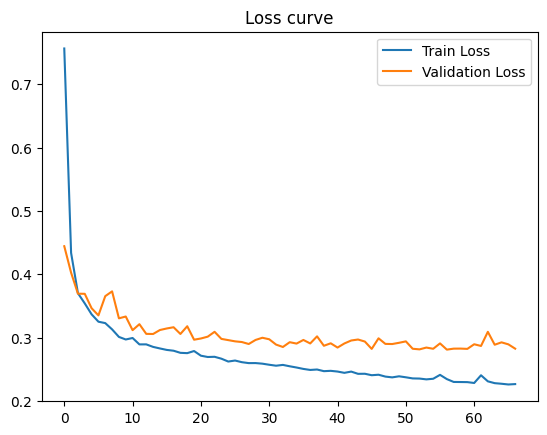

In [11]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss curve")
plt.show()

### Explanation:

#### Both training and validation loss decrease, indicating good learning behaviour.

## 11. Evaluation

In [12]:
test_loss,test_mae = model.evaluate(X_test,y_test)
print(test_loss, test_mae)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2496 - mae: 0.3313  
0.2495642602443695 0.33125513792037964


## 12. Prediction Analysis

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


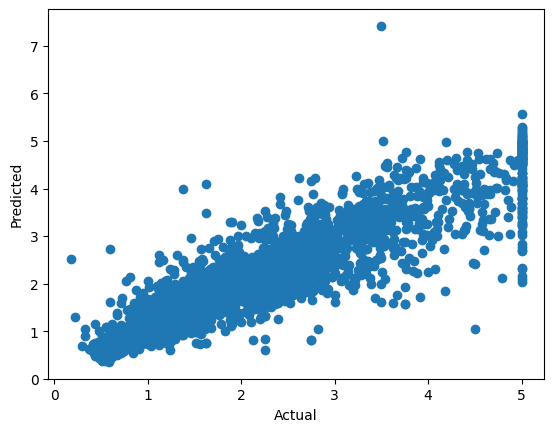

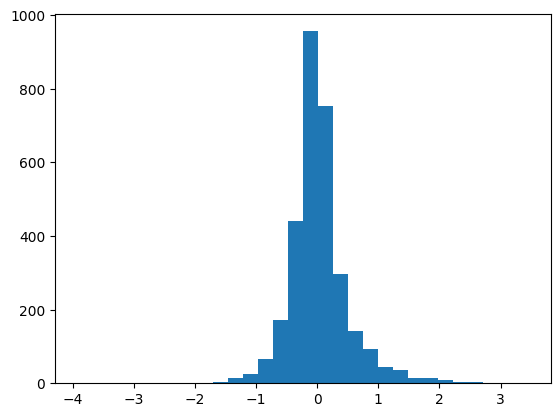

In [13]:
y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

residuals = y_test - y_pred.flatten()
plt.hist(residuals, bins=30)
plt.show()

### Explanation:

#### Predictions close to diagonal indicate good performance. Remainings centered near zero show balanced errors.

# REPORT ANSWERS

## 1. Dataset Overview

#### This dataset contains information about houses in different areas of California. The main aim is to predict the house price using features like income, number of rooms, population, etc.


## 2. EDA Insights

#### From the analysis, I observed that median income has strong relationship with house price. Some features are not equally distributed and show some asymmetry. Also, there are no missing values in the dataset.

## 3. preprocessing

#### In this step, the dataset is divided into training, validation, and testing parts. After that, feature scaling is applied so that all the values come into a similar range. This helps the model to learn better.

## 4. Model Architecture

#### Here, a deep learning model is created using multiple layers. ReLU activation function is used in hidden layers to learn complex patterns. The output layer has only one neuron since this is a regression problem.

## 5. Loss Function Justification

#### MSE is used as the loss function because it gives more importance to large errors. MAE is also used to understand the average error in prediction.

## 6. Training Process

#### The model is trained using the adam optimizer. Early stopping is used so that the model does not overfit the data. It stops training when there is no improvement.

## 7. Learning Curve Interpretation

#### From the graph, both training and validation loss are decreasing, which shows that the model is learning properly. There is no major overfitting observed.

## 8. Model Performance

#### The model gives a reasonable error on test data, which means it is performing well in predicting house prices.

## 9. Prediction Analysis

#### The predicted values are close to actual values in most cases, the remaining values are mostly around zero, which shows the model is fairly accurate.

## 10. Improvements

#### The model can be improved by adding dropout layers, tuning parameters, or trying different architectures.